<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Entrainement du modèle de base avec la création de données augmentées

</div>

In [2]:
%%time
# Installations

# pip install tensorflow
# pip install Pillow
# pip install matplotlib
# pip install scikit-learn
# pip install seaborn
# pip install pydot

import time

RecreerRepertoiresImages = False

# Bibliothèques principales
import numpy as np
from pathlib import Path
import os
from PIL import Image
import shutil
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import json

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import clone_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.utils import load_img

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")


# Reproductibilité
tf.random.set_seed(55)
np.random.seed(55)    
SEED = 55

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)

📦 Versions des bibliothèques :
  - TensorFlow : 2.21.0
  - Keras      : 3.13.2
  - NumPy      : 2.4.4
CPU times: total: 3.59 s
Wall time: 3.91 s


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Gestion du Dataset<br><br>

L'option est prise de sauvegarder physiquement les données augmentées dans un répertoire pour pouvoir les consulter.
Il apparait que certaines transformations parasitent un peu l'image.<br>

La préparation est classique avec normalisation à 224 pixels en couleurs et le rapport de 80% entre la partie entrainement et la partie test.

</div>

---------------------------------------------------------
# Dataset 
---------------------------------------------------------

In [3]:
%%time
# dataset

project_root = Path.cwd().parent
print("project_root : " + str(project_root))

data_dir = str(project_root) + "/CarDamageSeverityDataset"
data_dir = Path(data_dir)
print("data_dir:", data_dir)

IMG_SIZE = (224, 224)


project_root : c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning
data_dir: c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDataset
CPU times: total: 0 ns
Wall time: 1.01 ms


In [4]:
%%time
# Augmentation réelle du dataset

# CONFIG
INPUT_DIR = data_dir
OUTPUT_DIR = Path(str(project_root) + "/CarDamageSeverityDatasetAugmented")
AUG_PER_IMAGE = 5  # nombre d'images générées par image

# AUGMENTATION
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
])

if RecreerRepertoiresImages:

    # CRÉER DOSSIERS
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # TRAITEMENT
    for class_name in os.listdir(INPUT_DIR):
        class_input_path = os.path.join(INPUT_DIR, class_name)
        class_output_path = os.path.join(OUTPUT_DIR, class_name)

        os.makedirs(class_output_path, exist_ok=True)

        for img_name in os.listdir(class_input_path):
            img_path = os.path.join(class_input_path, img_name)

            # Charger image
            img = Image.open(img_path).resize(IMG_SIZE)
            img_array = np.array(img)
            img_array = np.expand_dims(img_array, axis=0)  # batch dimension

            # Sauvegarder image originale (optionnel)
            base_name = os.path.splitext(img_name)[0]

            for i in range(AUG_PER_IMAGE):
                augmented = data_augmentation(img_array, training=True)

                # Convertir en image
                aug_img = augmented[0].numpy().astype("uint8")
                aug_img = Image.fromarray(aug_img)

                # Sauvegarde
                new_name = f"{base_name}_aug_{i}.jpg"
                aug_img.save(os.path.join(class_output_path, new_name))

    print("Dataset augmenté créé ✅")


CPU times: total: 15.6 ms
Wall time: 21.8 ms


In [5]:
%%time
# Creation dataset complet : original + augmenté

data_dir_complet = str(project_root) + "/CarDamageSeverityDatasetComplet"
data_dir_complet = Path(data_dir_complet)
print("data_dir_complet :", data_dir_complet)

if RecreerRepertoiresImages:
    shutil.copytree(str(data_dir), str(data_dir_complet), dirs_exist_ok=True)   
    shutil.copytree(str(OUTPUT_DIR), str(data_dir_complet), dirs_exist_ok=True)   


data_dir_complet : c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDatasetComplet
CPU times: total: 0 ns
Wall time: 0 ns


In [6]:
%%time
# Analyse Dataset 

def analyse_dataset(p_chemin):

    # Explorer la structure
    print("\n📂 Structure du dataset : ", p_chemin)
    all_items = sorted([item.name for item in p_chemin.glob('*') if item.is_dir()])
    print(f"  - Tous les dossiers trouvés : {all_items}")

    class_names = all_items
    class_names = sorted(class_names)

    print(f"  - Nombre de classes : {len(class_names)}")

    if len(class_names) != 4:
        print("\n⚠️  Attention : Nombre de classes incorrect !")
        print("   Vérification du contenu du dataset...")

    # Compter les images par classe
    print("\n📊 Distribution des images par classe :")
    class_counts = {}
    total_images = 0
    for class_name in class_names:
        class_path = p_chemin / class_name
        count = len(list(class_path.glob('*.*')))
        class_counts[class_name] = count
        total_images += count
        print(f"  - {class_name:15s} : {count:4d} images")

    print(f"\n  - Total : {total_images} images")
    print(f"  - Moyenne par classe : {total_images / len(class_names):.0f} images")

    return class_names

class_names = analyse_dataset(data_dir)

class_names = analyse_dataset(data_dir_complet)



📂 Structure du dataset :  c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDataset
  - Tous les dossiers trouvés : ['00-normal', '01-minor', '02-moderate', '03-severe']
  - Nombre de classes : 4

📊 Distribution des images par classe :
  - 00-normal       :  633 images
  - 01-minor        :  550 images
  - 02-moderate     :  552 images
  - 03-severe       :  580 images

  - Total : 2315 images
  - Moyenne par classe : 579 images

📂 Structure du dataset :  c:\Users\huber_otpq54a\OneDrive\Documents\Formation\IA\Developpement\Projets\Deep_Learning\CarDamageSeverityDatasetComplet
  - Tous les dossiers trouvés : ['00-normal', '01-minor', '02-moderate', '03-severe']
  - Nombre de classes : 4

📊 Distribution des images par classe :
  - 00-normal       : 3798 images
  - 01-minor        : 3300 images
  - 02-moderate     : 3312 images
  - 03-severe       : 3480 images

  - Total : 13890 images
  - Moyenne par classe : 3472 images
CPU tim

In [7]:
%%time
#Préparation des datasets

data_dir = data_dir_complet



# Paramètres
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Créer le dataset d'entraînement avec filtrage des classes
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,       # redimensionne toutes les images automatiquement
    batch_size=BATCH_SIZE,     # nombre d’images envoyées au modèle à chaque itération
    label_mode='categorical',  # One-hot encoding pour multi-classe
    class_names=class_names
)

# for images, labels in train_ds:
#     print(images.shape, "   ", labels.shape)  # (32, 224, 224, 3)         (32, nb_classes)
    
# Créer le dataset de validation avec les mêmes classes
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    class_names=class_names  # Même ordre de classes
)

print(f"\n  - Train batches  : {len(train_ds)}")
print(f"  - Val batches    : {len(val_ds)}")
print(f"  - Batch size     : {BATCH_SIZE}")
print(f"  - Image size     : {IMG_SIZE}")
print(f"\n  - Train samples  : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds) * BATCH_SIZE}")

Found 13890 files belonging to 4 classes.
Using 11112 files for training.
Found 13890 files belonging to 4 classes.
Using 2778 files for validation.

  - Train batches  : 348
  - Val batches    : 87
  - Batch size     : 32
  - Image size     : (224, 224)

  - Train samples  : ~11136
  - Val samples    : ~2784
CPU times: total: 578 ms
Wall time: 495 ms


In [ ]:
%%time
# Prétraitement et (Data Augmentation)

# Créer un modèle d'augmentation de données plus agressif
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(factor=0.2),
], name="data_augmentation")

# Fonction pour appliquer le prétraitement
def normalize(x, y):
    return preprocess_input(x), y

def augment_fn(x, y):
    return data_augmentation(x, training=True), y

def prepare_dataset(ds, augment=False, shuffle=True):

    if shuffle:
        ds = ds.shuffle(1000)

    # 🔥 1. AUGMENTATION D’ABORD
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # 🔥 2. NORMALISATION ENSUITE
    ds = ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.cache()

    # Prefetch
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds


# Appliquer le prétraitement
train_ds_prepared = prepare_dataset(train_ds, augment=False, shuffle=True)         # Pas d'augmentation car fait précédemment
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)

print(f"\n  - Train batches  : {len(train_ds_prepared)}")
print(f"  - Val batches    : {len(val_ds_prepared)}")
print(f"\n  - Train samples  : ~{len(train_ds_prepared) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds_prepared) * BATCH_SIZE}")

Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x0000028D777C1120>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x0000028D777C1120>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x0000028D76FA8900>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function prepare_dataset.<locals>.<lambda> at 0x0000028D76FA8900>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert

  - Train batches  

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Chargement du modele MobileNetV2<br>

Ce modèle est choisi pour sa légèreté et donc sa rapidité d'entrainement. Il donne malgrès tout des résultats corrects dans notre cas de classification.
</div>

-------------------------------
# Modèle
-------------------------------

In [9]:
%%time

# Chargement MobileNetV2 pré-entraîné sans le classifier (include_top=False)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Charger les poids pré-entraînés sur ImageNet
    pooling='avg'  # Global Average Pooling à la fin
)

# Verouillage de toutes les couches une à une pour que ça apparaisse correctement à l'affichage des couches
for i, layer in enumerate(base_model.layers):
    layer.trainable = False

    
print("✅ Modèle MobileNetV2 chargé !\n")

# Afficher la structure du modèle
print("📋 Structure du modèle MobileNetV2 :")
print(f"  - Architecture   : MobileNetV2")
print(f"  - Input shape    : (224, 224, 3)")
print(f"  - Poids          : ImageNet (1000 classes)")
print(f"  - Output shape   : {base_model.output_shape}")
print(f"  - Nombre de couches : {len(base_model.layers)}")

# Compter les paramètres
total_params = base_model.count_params()
print(f"\n  - Nombre total de paramètres : {total_params:,}")
print(f"  - Taille en mémoire (approx.) : {total_params * 4 / (1024**2):.1f} MB")


✅ Modèle MobileNetV2 chargé !

📋 Structure du modèle MobileNetV2 :
  - Architecture   : MobileNetV2
  - Input shape    : (224, 224, 3)
  - Poids          : ImageNet (1000 classes)
  - Output shape   : (None, 1280)
  - Nombre de couches : 155

  - Nombre total de paramètres : 2,257,984
  - Taille en mémoire (approx.) : 8.6 MB
CPU times: total: 422 ms
Wall time: 413 ms


In [10]:
%%time
print("🔍 Aperçu des couches de MobileNetV2\n")
print("="*80)

# Fonction helper pour obtenir l'output shape
def get_output_shape(layer):
    try:
        if hasattr(layer, 'output_shape'):
            return str(layer.output_shape)
        elif hasattr(layer, 'output'):
            return str(layer.output.shape)
        else:
            return "N/A"
    except:
        return "N/A"

def affiche_couches(p_model):
    # Afficher les 15 premières et 15 dernières couches
    print("\n📌 Premières couches (extraction de features bas niveau) :")
    for i, layer in enumerate(p_model.layers[:15]):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n      ...")

    print("\n📌 Dernières couches (features haut niveau) :")
    for i, layer in enumerate(p_model.layers[-15:], start=len(p_model.layers)-15):
        output_shape = get_output_shape(layer)
        print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")

    print("\n" + "="*80)

#affiche_couches(base_model)

def print_layers(p_model, n=0):
    for i, layer in enumerate(p_model.layers):
        # print(prefix + layer.name)
        output_shape = get_output_shape(layer)
        if n==0:
            print(f"  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")
        else:
            print(f"  {n:3d}.  {i+1:3d}. {layer.name:40s} | Output: {output_shape:30s} | Trainable: {layer.trainable}")
        if hasattr(layer, "layers"):  # modèle imbriqué
            x = i + 1
            print_layers(layer, x)

print_layers(base_model)

🔍 Aperçu des couches de MobileNetV2

    1. input_layer                              | Output: (None, 224, 224, 3)            | Trainable: False
    2. Conv1                                    | Output: (None, 112, 112, 32)           | Trainable: False
    3. bn_Conv1                                 | Output: (None, 112, 112, 32)           | Trainable: False
    4. Conv1_relu                               | Output: (None, 112, 112, 32)           | Trainable: False
    5. expanded_conv_depthwise                  | Output: (None, 112, 112, 32)           | Trainable: False
    6. expanded_conv_depthwise_BN               | Output: (None, 112, 112, 32)           | Trainable: False
    7. expanded_conv_depthwise_relu             | Output: (None, 112, 112, 32)           | Trainable: False
    8. expanded_conv_project                    | Output: (None, 112, 112, 16)           | Trainable: False
    9. expanded_conv_project_BN                 | Output: (None, 112, 112, 16)           | Trainabl

In [11]:
%%time
# Feature Extraction : Transfert-Learning

# Obtenir les noms de classes
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"  - Classes        : {class_names}")
print(f"  - Nombre de classes : {num_classes}")

# Geler le modèle de base
base_model.trainable = False

# Architecture OPTIMALE pour ce dataset
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Classifier avec régularisation modérée
x = layers.Dropout(0.3)(x)  # Dropout modéré
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_frozen = keras.Model(inputs, outputs, name='MobileNetV2_Frozen')

# Compiler avec LR optimal
model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),  # LR standard
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

print("\n✅ Modèle compilé !\n")

trainable = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
print(f"  - Paramètres entraînables    : {trainable:,}")
print(f"  - Paramètres non-entraînables: {non_trainable:,}")
print(f"  - Total                      : {trainable + non_trainable:,}")

model_frozen.summary()

  - Classes        : ['00-normal', '01-minor', '02-moderate', '03-severe']
  - Nombre de classes : 4

✅ Modèle compilé !

  - Paramètres entraînables    : 328,964
  - Paramètres non-entraînables: 2,257,984
  - Total                      : 2,586,948


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

CPU times: total: 78.1 ms
Wall time: 68.1 ms


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Entraînement du modèle en mode gelé<br>

Cette première étape va permettre d'utiliser le modèle pré-entrainé tel quel 
en ne rajoutant en fin que des couches permettant notre classification en 4 classes.
</div>

--------------------
# Entraînement du modèle frozen
--------------------

In [ ]:
%%time

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,  # Patience raisonnable
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_frozen.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

class SaveImagesCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, output_dir="epoch_images", num_images=5):
        super().__init__()
        self.dataset = dataset
        self.output_dir = output_dir
        self.num_images = num_images

        # créer dossier principal
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        epoch_dir = os.path.join(self.output_dir, f"epoch_{epoch+1}")
        os.makedirs(epoch_dir, exist_ok=True)

        for images, _ in self.dataset.take(1):
            for i in range(self.num_images):
                img = images[i].numpy()
                
                #print(img.min(), img.max())
                # dénormalisation MobileNetV2 (-1,1 → 0,1)
                #img = (img + 1.0) / 2.0
                img = ((img + 1.0) / 2.0 * 255).astype("uint8")
                #print(img.min(), img.max())

                # sauvegarde
                filepath = os.path.join(epoch_dir, f"img_{i}.png")
                plt.imsave(filepath, img)

        print(f"Images sauvegardées dans : {epoch_dir}")

callback = SaveImagesCallback(train_ds_prepared)


EPOCHS_FROZEN = 30

history_frozen = model_frozen.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FROZEN,
    callbacks=[early_stopping, reduce_lr, checkpoint, callback],
    verbose=1
)

print("\n✅ Entraînement frozen terminé !")
print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

best_val_acc = max(history_frozen.history['val_accuracy'])
best_epoch = history_frozen.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

if best_val_acc < 0.70:
    print(f"\n⚠️  Accuracy de {best_val_acc*100:.1f}% est en dessous de 70%")
    print("   Le modèle pourrait bénéficier de plus d'entraînement.")
elif best_val_acc < 0.80:
    print(f"\n✅ Bon résultat : {best_val_acc*100:.1f}%")
else:
    print(f"\n🎯 Excellent ! Accuracy de {best_val_acc*100:.1f}%")
    

Epoch 1/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5546 - loss: 3.7443 - top2_accuracy: 0.7873-1.0 0.92941177
0 246
-1.0 0.90588236
0 243
-1.0 1.0
0 255
-0.75686276 0.8509804
30 236
-0.94509804 1.0
6 255
Images sauvegardées dans : epoch_images\epoch_1
348/348 ━━━━━━━━━━━━━━━━━━━━ 72s 193ms/step - accuracy: 0.6077 - loss: 2.6075 - top2_accuracy: 0.8335 - val_accuracy: 0.6609 - val_loss: 1.3446 - val_top2_accuracy: 0.8812 - learning_rate: 0.0010
Epoch 2/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.6441 - loss: 1.2570 - top2_accuracy: 0.8685-1.0 0.92941177
0 246
-1.0 0.90588236
0 243
-1.0 1.0
0 255
-0.75686276 0.8509804
30 236
-0.94509804 1.0
6 255
Images sauvegardées dans : epoch_images\epoch_2
348/348 ━━━━━━━━━━━━━━━━━━━━ 66s 190ms/step - accuracy: 0.6461 - loss: 1.1805 - top2_accuracy: 0.8670 - val_accuracy: 0.6285 - val_loss: 1.0489 - val_top2_accuracy: 0.8693 - learning_rate: 0.0010
Epoch 3/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.65

KeyboardInterrupt: 

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Evaluation de cet entrainement<br>

</div>

Epoch optimal détecté : 29 avec val_loss = 0.7267


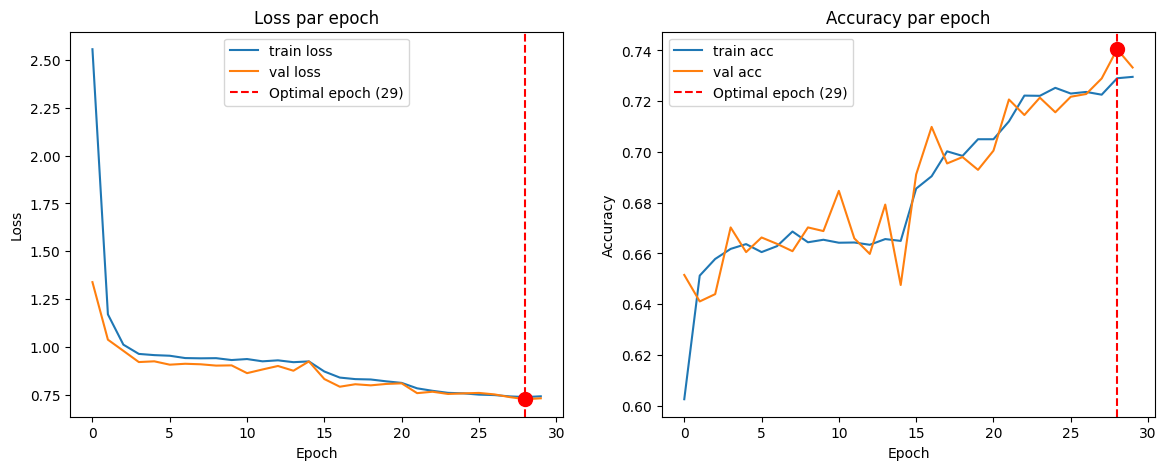

CPU times: total: 156 ms
Wall time: 213 ms


In [ ]:
%%time

def evaluation(p_history):
    # Epoch optimal (val_loss minimal)
    val_loss = p_history.history['val_loss']
    optimal_epoch = np.argmin(val_loss)
    optimal_val_loss = val_loss[optimal_epoch]
    print(f"Epoch optimal détecté : {optimal_epoch + 1} avec val_loss = {optimal_val_loss:.4f}")

    # Tracer loss et accuracy avec repère
    plt.figure(figsize=(14,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(p_history.history['loss'], label='train loss')
    plt.plot(p_history.history['val_loss'], label='val loss')
    plt.axvline(optimal_epoch, color='r', linestyle='--', label=f'Optimal epoch ({optimal_epoch + 1})')
    plt.scatter(optimal_epoch, optimal_val_loss, color='red', s=100, zorder=5)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss par epoch')
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(p_history.history['accuracy'], label='train acc')
    plt.plot(p_history.history['val_accuracy'], label='val acc')
    plt.axvline(optimal_epoch, color='r', linestyle='--', label=f'Optimal epoch ({optimal_epoch + 1})')
    plt.scatter(optimal_epoch, p_history.history['val_accuracy'][optimal_epoch], color='red', s=100, zorder=5)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy par epoch')
    plt.legend()

    plt.show()

evaluation(history_frozen)

87/87 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step


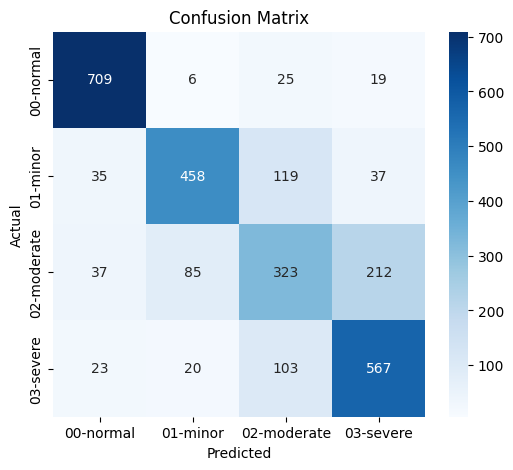

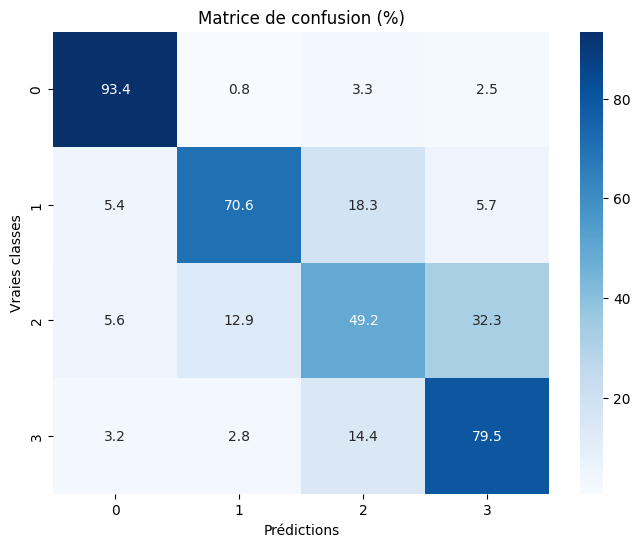


📄 Rapport de classification détaillé :

              precision    recall  f1-score   support

   00-normal      0.882     0.934     0.907       759
    01-minor      0.805     0.706     0.752       649
 02-moderate      0.567     0.492     0.526       657
   03-severe      0.679     0.795     0.733       713

    accuracy                          0.740      2778
   macro avg      0.733     0.732     0.730      2778
weighted avg      0.737     0.740     0.736      2778

CPU times: total: 2min 44s
Wall time: 15.5 s


In [ ]:
%%time
# Matrice de confusion

def matrice_confusion(p_model, p_dataset):
    y_val = np.concatenate([y for x, y in p_dataset], axis=0)
    y_val = np.argmax(y_val, axis=1)
    y_pred_probs = p_model.predict(p_dataset)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Normalisation par ligne (chaque ligne = 100%)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    # Conversion en pourcentage
    cm_percent = cm_norm * 100

    # Affichage
    plt.figure(figsize=(8,6))
    sns.heatmap(cm_percent, 
                annot=True, 
                fmt=".1f", 
                cmap="Blues")

    plt.xlabel('Prédictions')
    plt.ylabel('Vraies classes')
    plt.title('Matrice de confusion (%)')

    plt.show()

    # Rapport de classification
    print("\n📄 Rapport de classification détaillé :\n")
    print(classification_report(y_val, y_pred_classes, target_names=class_names, digits=3))


matrice_confusion(model_frozen, val_ds_prepared)


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Fine-Tuning<br>

Dans cette étape on va dégeler une partie des couches du modèle et l'entrainer en gardant un coefficiant de correction des poids du modèle initial très bas pour ne pas perturber le pré-entrainement initial mais en applicant quand même de petites corrections correspondant à nos données propres. 
</div>

--------------------------
# Fine-Tuning
--------------------------

In [ ]:
%%time

# Évaluation AVANT fine-tuning
print("📈 Performance AVANT fine-tuning :")
results_before = model_frozen.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_before[1]*100:.2f}%")
print(f"  - Loss     : {results_before[0]:.4f}\n")

# clone du modèle avec ses poids
# model_finetuned = clone_model(model_frozen)
# model_finetuned.set_weights(model_frozen.get_weights())

# Dégeler le base_model
base_model.trainable = True

# Geler seulement les 100 premières couches
fine_tune_at = 100

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print(f"📊 Configuration du dégel :")
print(f"  - Couches frozen  : {fine_tune_at}")
print(f"  - Couches unfrozen: {len(base_model.layers) - fine_tune_at}")

# Compter les paramètres
trainable_count = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])
total = trainable_count + non_trainable_count

print(f"  - Paramètres entraînables : {trainable_count:,} ({trainable_count/total*100:.1f}%)")
print(f"  - Paramètres frozen       : {non_trainable_count:,}\n")

# Recompiler avec un LR très faible
FINE_TUNE_LR = 1e-5  # LR très faible

model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

# Le modèle fine-tuned est le modèle frozen modifié
model_finetuned = model_frozen

print_layers(model_finetuned)

print(f"✅ Modèle recompilé avec LR = {FINE_TUNE_LR}")
print("\n💡 Le modèle va continuer depuis les poids déjà appris.")

# Vérification immédiate
print("\n🔍 Vérification immédiate :")
results_after_compile = model_finetuned.evaluate(val_ds_prepared, verbose=0)
print(f"  - Accuracy : {results_after_compile[1]*100:.2f}%")
print(f"  - Loss     : {results_after_compile[0]:.4f}")

if abs(results_after_compile[1] - results_before[1]) < 0.01:
    print(f"\n  ✅ Parfait ! Les poids sont préservés ({results_after_compile[1]*100:.1f}%)")
else:
    print(f"\n  ⚠️  Les performances ont changé après recompilation")

📈 Performance AVANT fine-tuning :
  - Accuracy : 74.05%
  - Loss     : 0.7267

📊 Configuration du dégel :
  - Couches frozen  : 100
  - Couches unfrozen: 55
  - Paramètres entraînables : 2,190,404 (84.7%)
  - Paramètres frozen       : 396,544

    1. input_layer_2                            | Output: (None, 224, 224, 3)            | Trainable: True
    2. mobilenetv2_1.00_224                     | Output: (None, 1280)                   | Trainable: True
    2.    1. input_layer_1                            | Output: (None, 224, 224, 3)            | Trainable: False
    2.    2. Conv1                                    | Output: (None, 112, 112, 32)           | Trainable: False
    2.    3. bn_Conv1                                 | Output: (None, 112, 112, 32)           | Trainable: False
    2.    4. Conv1_relu                               | Output: (None, 112, 112, 32)           | Trainable: False
    2.    5. expanded_conv_depthwise                  | Output: (None, 112, 112, 32)  

-------------------------------
# Entraînement du modèle fine-tuned
-------------------------------

In [ ]:
%%time

print("🚀 Fine-tuning du modèle...\n")
print("⚠️  Le modèle continue depuis les poids frozen déjà entraînés\n")

# Callbacks pour fine-tuning
early_stopping_ft = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,  # Beaucoup de patience
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr_ft = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = callbacks.ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=0
)

# Entraînement
EPOCHS_FINETUNE = 50

print(f"Entraînement pour {EPOCHS_FINETUNE} epochs maximum...\n")

history_finetuned = model_finetuned.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stopping_ft, reduce_lr_ft, checkpoint_ft],
    verbose=1
)

print("\n✅ Fine-tuning terminé !")
print(f"   Nombre d'epochs effectués : {len(history_finetuned.history['loss'])}")

# Meilleures performances
best_val_acc = max(history_finetuned.history['val_accuracy'])
best_epoch = history_finetuned.history['val_accuracy'].index(best_val_acc) + 1
print(f"   Meilleure val_accuracy : {best_val_acc*100:.2f}% (epoch {best_epoch})")

# Comparaison
frozen_best = max(history_frozen.history['val_accuracy'])
improvement = (best_val_acc - frozen_best) * 100
print(f"\n📊 Amélioration vs Frozen : {improvement:+.2f} points de pourcentage")
print(f"   - Frozen    : {frozen_best*100:.2f}%")
print(f"   - Fine-tuned: {best_val_acc*100:.2f}%")

🚀 Fine-tuning du modèle...

⚠️  Le modèle continue depuis les poids frozen déjà entraînés

Entraînement pour 50 epochs maximum...

Epoch 1/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 106s 287ms/step - accuracy: 0.6794 - loss: 0.8394 - top2_accuracy: 0.8937 - val_accuracy: 0.7027 - val_loss: 0.8273 - val_top2_accuracy: 0.9021 - learning_rate: 1.0000e-05
Epoch 2/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 98s 281ms/step - accuracy: 0.7395 - loss: 0.7147 - top2_accuracy: 0.9269 - val_accuracy: 0.7048 - val_loss: 0.8360 - val_top2_accuracy: 0.9075 - learning_rate: 1.0000e-05
Epoch 3/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 97s 279ms/step - accuracy: 0.7703 - loss: 0.6473 - top2_accuracy: 0.9414 - val_accuracy: 0.7235 - val_loss: 0.7858 - val_top2_accuracy: 0.9161 - learning_rate: 1.0000e-05
Epoch 4/50
348/348 ━━━━━━━━━━━━━━━━━━━━ 97s 279ms/step - accuracy: 0.7981 - loss: 0.5879 - top2_accuracy: 0.9550 - val_accuracy: 0.7433 - val_loss: 0.7264 - val_top2_accuracy: 0.9287 - learning_rate: 1.0000e-05
Epoch 5/50
348/348 ━━━━━

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Evaluation du modèle entrainé en Fine-Tuning<br>

</div>

Epoch optimal détecté : 11 avec val_loss = 0.5794


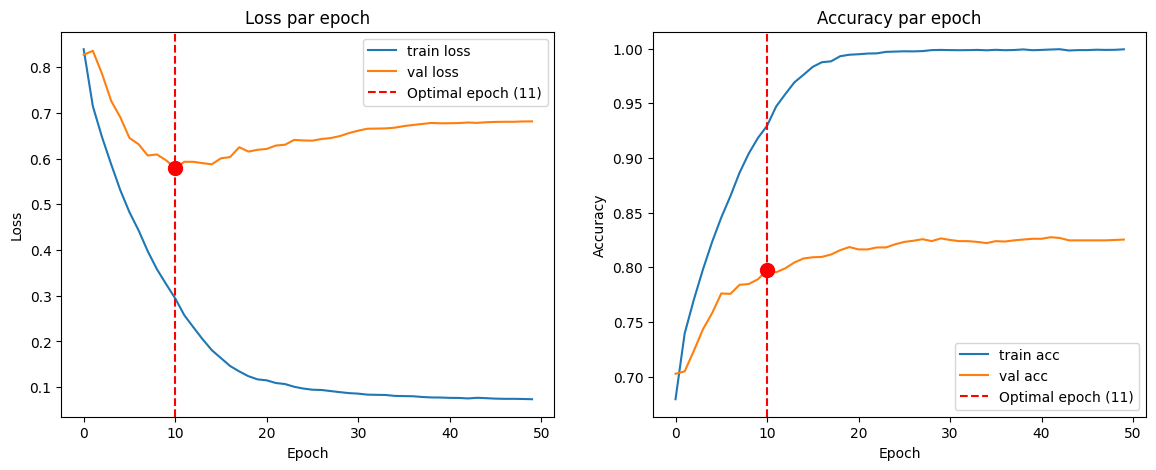

CPU times: total: 125 ms
Wall time: 127 ms


In [ ]:
%%time

evaluation(history_finetuned)

87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step


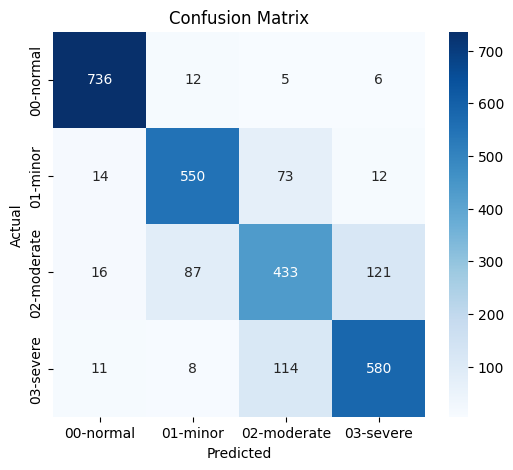

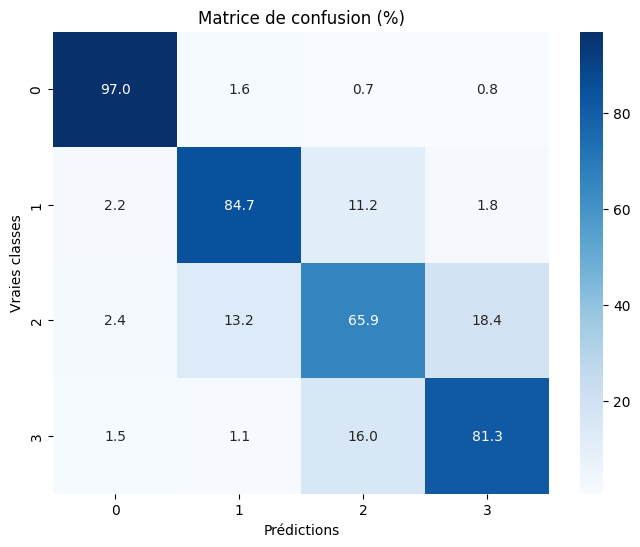


📄 Rapport de classification détaillé :

              precision    recall  f1-score   support

   00-normal      0.947     0.970     0.958       759
    01-minor      0.837     0.847     0.842       649
 02-moderate      0.693     0.659     0.676       657
   03-severe      0.807     0.813     0.810       713

    accuracy                          0.828      2778
   macro avg      0.821     0.822     0.822      2778
weighted avg      0.825     0.828     0.826      2778

CPU times: total: 2min 45s
Wall time: 14.4 s


In [ ]:

%%time

matrice_confusion(model_finetuned, val_ds_prepared)

<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Sauvegarde de cette version du modèle<br>

</div>

In [ ]:
%%time

# Sauvegarde du modèle

# Sauvegarder au format Keras (.keras)
model_path = 'mobilenetv2_test1_finetuned.keras'
model_finetuned.save(model_path)

with open("mobilenetv2_test1_finetuned_class_names.json", "w") as f:
    json.dump(class_names, f)

print(f"\n✅ Modèle sauvegardé : {model_path}")
print(f"   Taille du fichier : {os.path.getsize(model_path) / (1024**2):.1f} MB")

# Sauvegarder aussi au format h5 (legacy)
model_h5_path = 'mobilenetv2_test1_finetuned.h5'
model_finetuned.save(model_h5_path)
print(f"\n✅ Modèle également sauvegardé en .h5 : {model_h5_path}")


# Pour recharger le modèle
# loaded_model = keras.models.load_model(model_path)



✅ Modèle sauvegardé : mobilenetv2_test1_finetuned.keras
   Taille du fichier : 27.2 MB

✅ Modèle également sauvegardé en .h5 : mobilenetv2_test1_finetuned.h5
CPU times: total: 422 ms
Wall time: 422 ms


<div style="background-color:#FFECB3; color:black; padding:10px; border-radius:5px;">

Test de cette version du modèle<br>

</div>

---------------------------------------
# Test
---------------------------------------

In [ ]:
%%time

# Fonction de prédiction

def predict_image(model, image_path, class_names):
    
    # Charger et prétraiter l'image
    img = load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Ajouter dimension batch
    img_array = preprocess_input(img_array)  # Normalisation MobileNetV2
    
    # Prédire
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx]
    
    # Top 3 prédictions
    top3_idx = np.argsort(predictions[0])[-3:][::-1]
    
    return {
        'predicted_class': class_names[predicted_class_idx],
        'confidence': confidence,
        'all_probabilities': predictions[0],
        'top3': [(class_names[i], predictions[0][i]) for i in top3_idx]
    }

print("✅ Fonction de prédiction créée !")

✅ Fonction de prédiction créée !
CPU times: total: 0 ns
Wall time: 0 ns


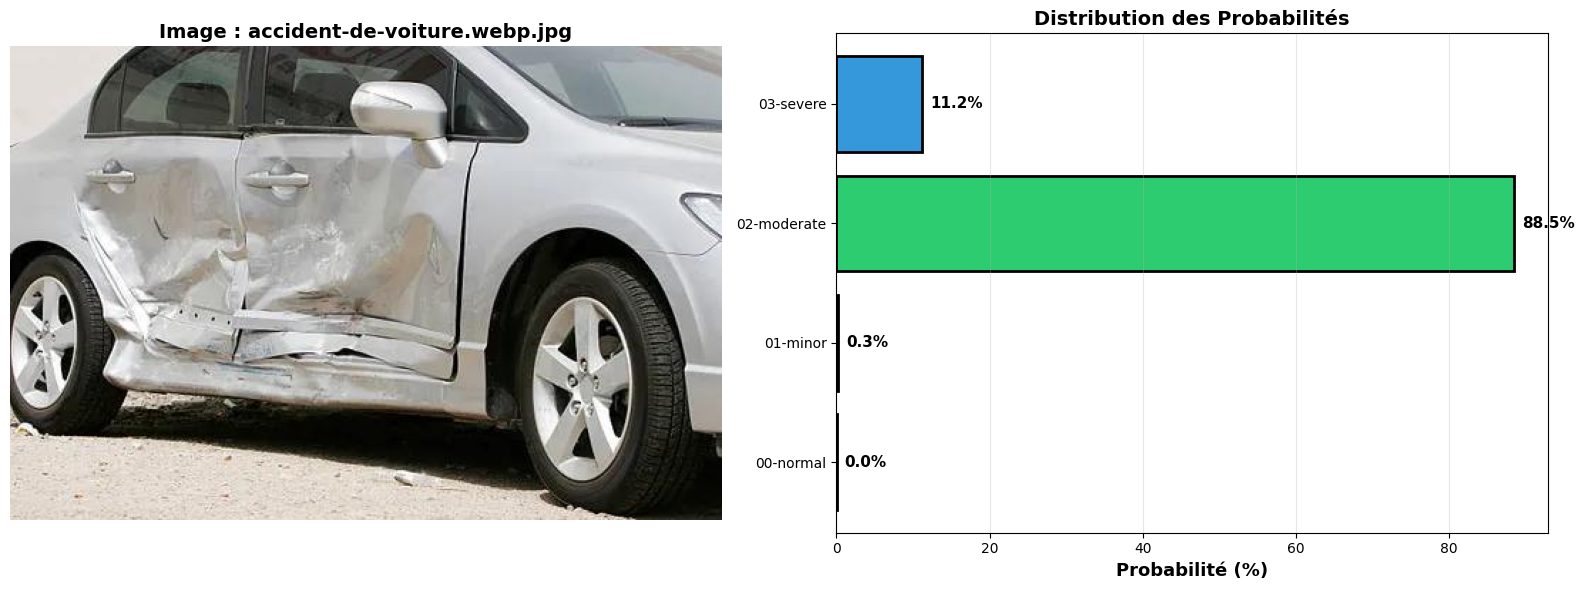


🔍 Analyse de la prédiction :
  - Classe prédite : 02-moderate
  - Confiance      : 88.52%

  - Top 3 prédictions :
    1. 02-moderate     : 88.52%
    2. 03-severe       : 11.21%
    3. 01-minor        : 0.25%
CPU times: total: 1.67 s
Wall time: 1.7 s


In [ ]:
%%time

model_path = 'mobilenetv2_test1_finetuned.keras'
loaded_model = keras.models.load_model(model_path)
class_names = ["00-normal", "01-minor", "02-moderate", "03-severe"]

# Visualisation des probabilités pour une image

from PIL import Image

# Prendre une image spécifique
sample_image_path = "C:/Users/huber_otpq54a/OneDrive/Documents/Formation/IA/Developpement/Projets/Deep_Learning/Test/accident-de-voiture.webp"

im = Image.open(sample_image_path).convert("RGB")
sample_image_path = sample_image_path + ".jpg"
im.save(sample_image_path, "JPEG")

result = predict_image(loaded_model, sample_image_path, class_names)

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Image
img = plt.imread(sample_image_path)
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title(f"Image : {str(Path(sample_image_path).name)}", fontsize=14, fontweight='bold')

# Probabilités
probs = result['all_probabilities'] * 100
colors = ['#2ecc71' if i == np.argmax(probs) else '#3498db' for i in range(len(probs))]

bars = axes[1].barh(class_names, probs, color=colors, edgecolor='black', linewidth=2)
axes[1].set_xlabel('Probabilité (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Distribution des Probabilités', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Ajouter les valeurs
for bar, prob in zip(bars, probs):
    width = bar.get_width()
    axes[1].text(width + 1, bar.get_y() + bar.get_height()/2.,
                f'{prob:.1f}%',
                ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n🔍 Analyse de la prédiction :")
print(f"  - Classe prédite : {result['predicted_class']}")
print(f"  - Confiance      : {result['confidence']*100:.2f}%")
print(f"\n  - Top 3 prédictions :")
for i, (cls, prob) in enumerate(result['top3'], 1):
    print(f"    {i}. {cls:15s} : {prob*100:.2f}%")